In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 400

age = np.random.randint(21, 60, N)
monthly_income_inr = np.random.randint(15000, 150000, N)
existing_loans_count = np.random.randint(0, 5, N)
credit_utilization_ratio = np.round(np.random.uniform(0.05, 0.95, N), 2)
upi_monthly_inflow_inr = np.random.randint(2000, 120000, N)
bounced_payments_count = np.random.poisson(1.2, N)
employment_type = np.random.choice(["salaried", "self_employed", "gig"], N,
                                    p=[0.55, 0.30, 0.15])
credit_bureau_score = np.random.randint(300, 900, N).astype(float)

# 20% of applicants are "new to credit" (thin-file): no bureau score at all
thin_file_idx = np.random.choice(N, size=int(0.20 * N), replace=False)
credit_bureau_score[thin_file_idx] = np.nan

# risk score combines income (protective), bounced payments and utilization (risky),
# and UPI inflow (protective, alternate-data signal) -- deliberately usable even
# when credit_bureau_score is missing
z_income = (monthly_income_inr - monthly_income_inr.mean()) / monthly_income_inr.std()
z_bounced = (bounced_payments_count - bounced_payments_count.mean()) / (bounced_payments_count.std() + 1e-9)
z_util = (credit_utilization_ratio - credit_utilization_ratio.mean()) / credit_utilization_ratio.std()
z_upi = (upi_monthly_inflow_inr - upi_monthly_inflow_inr.mean()) / upi_monthly_inflow_inr.std()

risk_score = -2.25 + (-0.9 * z_income) + (0.8 * z_bounced) + (0.7 * z_util) + (-0.5 * z_upi) \
    + np.random.normal(0, 0.6, N)
default_prob = 1 / (1 + np.exp(-risk_score))
default = (np.random.uniform(0, 1, N) < default_prob).astype(int)

df = pd.DataFrame({
    "applicant_id": [f"APP{1000+i}" for i in range(N)],
    "age": age,
    "monthly_income_inr": monthly_income_inr,
    "existing_loans_count": existing_loans_count,
    "credit_utilization_ratio": credit_utilization_ratio,
    "upi_monthly_inflow_inr": upi_monthly_inflow_inr,
    "bounced_payments_count": bounced_payments_count,
    "credit_bureau_score": credit_bureau_score,
    "employment_type": employment_type,
    "default": default,
})
df.to_csv("credit_applicants.csv", index=False)
print(df["default"].value_counts(normalize=True))

# --- second dataset: transaction-behaviour rows for anomaly detection ---
M = 250
behaviour = pd.DataFrame({
    "txn_id": [f"BTXN{5000+i}" for i in range(M)],
    "applicant_id": np.random.choice(df["applicant_id"], M),
    "txn_hour": np.random.randint(6, 23, M),
    "is_new_device": np.random.choice([0, 1], M, p=[0.9, 0.1]),
    "txn_amount_inr": np.random.choice([199, 499, 999, 1999, 3999], M,
                                        p=[0.30, 0.28, 0.22, 0.13, 0.07]),
    "channel": np.random.choice(["P2P", "P2M"], M, p=[0.4, 0.6]),
})
# inject 15 deliberate anomalies: new device, unusual hour (1-4am), high amount
anomalies = pd.DataFrame({
    "txn_id": [f"BTXNA{i}" for i in range(15)],
    "applicant_id": np.random.choice(df["applicant_id"], 15),
    "txn_hour": np.random.randint(1, 5, 15),
    "is_new_device": 1,
    "txn_amount_inr": np.random.choice([14999, 19999, 24999], 15),
    "channel": "P2P",
})
behaviour = pd.concat([behaviour, anomalies], ignore_index=True)  # 265 rows total
behaviour.to_csv("txn_behaviour.csv", index=False)


default
0    0.7975
1    0.2025
Name: proportion, dtype: float64


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("credit_applicants.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 400
Columns: 10


In [3]:
df.head()

,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,default
0,APP1000,59,41646,4,0.80,17398,2,NaN,salaried,1
1,APP1001,49,119185,0,0.08,58503,3,380.0,salaried,0
2,APP1002,35,38049,0,0.59,8638,1,788.0,salaried,1
3,APP1003,28,113116,0,0.26,8570,2,387.0,salaried,0
4,APP1004,41,112379,2,0.16,70785,3,493.0,salaried,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   applicant_id              400 non-null    object 
 1   age                       400 non-null    int64  
 2   monthly_income_inr        400 non-null    int64  
 3   existing_loans_count      400 non-null    int64  
 4   credit_utilization_ratio  400 non-null    float64
 5   upi_monthly_inflow_inr    400 non-null    int64  
 6   bounced_payments_count    400 non-null    int64  
 7   credit_bureau_score       320 non-null    float64
 8   employment_type           400 non-null    object 
 9   default                   400 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 31.4+ KB


In [5]:
missing_values = df.isnull().sum()

print(missing_values)

applicant_id                 0
age                          0
monthly_income_inr           0
existing_loans_count         0
credit_utilization_ratio     0
upi_monthly_inflow_inr       0
bounced_payments_count       0
credit_bureau_score         80
employment_type              0
default                      0
dtype: int64


In [6]:
missing_bureau_count = df["credit_bureau_score"].isna().sum()

missing_bureau_percentage = (missing_bureau_count
    / len(df)
    * 100)

print("Missing bureau scores:", missing_bureau_count)

print("Missing bureau score percentage:",round(missing_bureau_percentage, 2),"%")

Missing bureau scores: 80
Missing bureau score percentage: 20.0 %


In [7]:
default_rate = df["default"].mean() * 100

print("Default rate:",round(default_rate, 2),"%")

Default rate: 20.25 %


In [8]:
df["default"].value_counts()

,count
default,
0,319
1,81


In [9]:
df["default"].value_counts(normalize=True) * 100

,proportion
default,
0,79.75
1,20.25


In [10]:
df["is_thin_file"] = (
    df["credit_bureau_score"].isna()
).astype(int)

In [11]:
df["is_thin_file"].value_counts()

,count
is_thin_file,
0,320
1,80


In [12]:
pd.crosstab(
    df["is_thin_file"],
    df["credit_bureau_score"].isna())

credit_bureau_score,False,True
is_thin_file,,
0,320,0
1,0,80


In [13]:
df.describe()

,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,default,is_thin_file
count,400.000000,400.00000,400.000000,400.00000,400.000000,400.000000,320.00000,400.000000,400.000000
mean,40.895000,80401.33250,1.937500,0.50630,62311.332500,1.217500,601.80000,0.202500,0.200000
std,11.525235,39565.41542,1.429581,0.26983,35032.772817,1.090029,171.93156,0.402366,0.400501
min,21.000000,15404.00000,0.000000,0.05000,2207.000000,0.000000,302.00000,0.000000,0.000000
25%,31.000000,42630.25000,1.000000,0.26000,32427.750000,0.000000,439.75000,0.000000,0.000000
50%,42.000000,80749.00000,2.000000,0.51500,62404.500000,1.000000,610.50000,0.000000,0.000000
75%,51.000000,116683.25000,3.000000,0.74000,94188.750000,2.000000,751.00000,0.000000,0.000000
max,59.000000,149668.00000,4.000000,0.95000,119867.000000,5.000000,898.00000,1.000000,1.000000


In [14]:
df["employment_type"].value_counts()

,count
employment_type,
salaried,230
self_employed,114
gig,56


In [15]:
pd.crosstab(
    df["employment_type"],
    df["is_thin_file"])

is_thin_file,0,1
employment_type,,
gig,41,15
salaried,182,48
self_employed,97,17


In [16]:
df.groupby("is_thin_file")["default"].mean() * 100

,default
is_thin_file,
0,19.6875
1,22.5000


In [17]:
df.groupby("default")[
    "monthly_income_inr"
].mean()

,monthly_income_inr
default,
0,85971.802508
1,58463.308642


In [18]:
df.groupby("default")[
    "credit_utilization_ratio"
].mean()

,credit_utilization_ratio
default,
0,0.476646
1,0.623086


In [19]:
df.groupby("default")[
    "bounced_payments_count"
].mean()

,bounced_payments_count
default,
0,1.062696
1,1.827160


In [20]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total applicants",
        "Default rate",
        "Missing bureau scores",
        "Missing bureau percentage",
        "Thin-file applicants"],
    "Value": [
        len(df),
        f"{default_rate:.2f}%",
        missing_bureau_count,
        f"{missing_bureau_percentage:.2f}%",
        df["is_thin_file"].sum()]})
eda_summary

,Metric,Value
0,Total applicants,400
1,Default rate,20.25%
2,Missing bureau scores,80
3,Missing bureau percentage,20.00%
4,Thin-file applicants,80


In [21]:
df.to_csv(
    "credit_applicants_eda.csv",
    index=False)

print("EDA dataset saved.")

EDA dataset saved.


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = df.drop(columns=["default"])
y = df["default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 10)
y shape: (400,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42)

In [25]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 300
Testing rows: 100


In [26]:
print("Overall default rate:")
print(y.mean())

print("\nTraining default rate:")
print(y_train.mean())

print("\nTesting default rate:")
print(y_test.mean())

Overall default rate:
0.2025

Training default rate:
0.20333333333333334

Testing default rate:
0.2


In [27]:
bureau_median = X_train[
    "credit_bureau_score"
].median()

print("Training-only bureau score median:",bureau_median)

Training-only bureau score median: 612.0


In [28]:
print("Missing bureau scores in training:", X_train["credit_bureau_score"].isna().sum())

print("Missing bureau scores in testing:", X_test["credit_bureau_score"].isna().sum())

Missing bureau scores in training: 62
Missing bureau scores in testing: 18


In [29]:
X_train["credit_bureau_score"] = (
    X_train["credit_bureau_score"]
    .fillna(bureau_median))

X_test["credit_bureau_score"] = (
    X_test["credit_bureau_score"]
    .fillna(bureau_median))

In [30]:
print("Missing bureau scores after imputation:")

print("Training:", X_train["credit_bureau_score"].isna().sum())

print("Testing:",X_test["credit_bureau_score"].isna().sum())

Missing bureau scores after imputation:
Training: 0
Testing: 0


In [31]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 300
Testing rows: 100


In [32]:
print(X_train["is_thin_file"].value_counts())

print()

print(X_test["is_thin_file"].value_counts())

is_thin_file
0    238
1     62
Name: count, dtype: int64

is_thin_file
0    82
1    18
Name: count, dtype: int64


In [33]:
print("PREPROCESSING CHECK")

print("Total applicants:", len(df))
print("Training applicants:", len(X_train))
print("Testing applicants:", len(X_test))

print("Training missing bureau scores:",X_train["credit_bureau_score"].isna().sum())

print("Testing missing bureau scores:",X_test["credit_bureau_score"].isna().sum())

print("Training thin-file applicants:",X_train["is_thin_file"].sum())

print("Testing thin-file applicants:",X_test["is_thin_file"].sum())

print("Training median used:",bureau_median)

PREPROCESSING CHECK
Total applicants: 400
Training applicants: 300
Testing applicants: 100
Training missing bureau scores: 0
Testing missing bureau scores: 0
Training thin-file applicants: 62
Testing thin-file applicants: 18
Training median used: 612.0


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [35]:
numeric_features = [
    "age",
    "monthly_income_inr",
    "existing_loans_count",
    "credit_utilization_ratio",
    "upi_monthly_inflow_inr",
    "bounced_payments_count",
    "credit_bureau_score",
    "is_thin_file"]

categorical_features = ["employment_type"]

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",
            StandardScaler(),
            numeric_features),
        ("cat",
            OneHotEncoder(
                handle_unknown="ignore"),
            categorical_features)])

In [37]:
handle_unknown="ignore"

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [39]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)
print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (300, 10)
Processed training shape: (300, 11)
Original test shape: (100, 10)
Processed test shape: (100, 11)


In [40]:
feature_names = (preprocessor.get_feature_names_out())

print(feature_names)

['num__age' 'num__monthly_income_inr' 'num__existing_loans_count'
 'num__credit_utilization_ratio' 'num__upi_monthly_inflow_inr'
 'num__bounced_payments_count' 'num__credit_bureau_score'
 'num__is_thin_file' 'cat__employment_type_gig'
 'cat__employment_type_salaried' 'cat__employment_type_self_employed']


In [41]:
# X_train = X_train.drop(columns=["applicant_id"])

# X_test = X_test.drop(columns=["applicant_id"])

In [42]:
print(X_train.columns.tolist())

['applicant_id', 'age', 'monthly_income_inr', 'existing_loans_count', 'credit_utilization_ratio', 'upi_monthly_inflow_inr', 'bounced_payments_count', 'credit_bureau_score', 'employment_type', 'is_thin_file']


In [43]:
numeric_features = [
    "age",
    "monthly_income_inr",
    "existing_loans_count",
    "credit_utilization_ratio",
    "upi_monthly_inflow_inr",
    "bounced_payments_count",
    "credit_bureau_score",
    "is_thin_file"]

categorical_features = ["employment_type"]

preprocessor = ColumnTransformer(
    transformers=[(
            "num",
            StandardScaler(),
            numeric_features),(
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"),
            categorical_features)])

In [44]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [45]:
print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

print("Training feature count:",
    len(preprocessor.get_feature_names_out()))

Training processed shape: (300, 11)
Testing processed shape: (100, 11)
Training feature count: 11


In [46]:
print("Training-only bureau median:", bureau_median)

print("Remaining training missing values:", X_train["credit_bureau_score"].isna().sum())

print("Remaining testing missing values:", X_test["credit_bureau_score"].isna().sum())

Training-only bureau median: 612.0
Remaining training missing values: 0
Remaining testing missing values: 0


In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42)

In [49]:
logistic_model.fit(
    X_train_processed,
    y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [50]:
y_pred_logistic = logistic_model.predict(
    X_test_processed)

In [51]:
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [52]:
print("First 10 predicted classes:")
print(y_pred_logistic[:10])

print("\nFirst 10 default probabilities:")
print(np.round(y_prob_logistic[:10],3))

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 0]

First 10 default probabilities:
[0.005 0.946 0.065 0.151 0.022 0.165 0.233 0.005 0.306 0.194]


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report)

In [54]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic)

print("Accuracy:",round(accuracy_logistic, 4))

Accuracy: 0.76


In [55]:
precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0)

print("Precision:",round(precision_logistic, 4))

Precision: 0.3889


In [56]:
recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0)

print("Recall:",round(recall_logistic, 4))

Recall: 0.35


In [57]:
f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0)

print("F1-score:",round(f1_logistic, 4))

F1-score: 0.3684


In [58]:
roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic)

print("ROC-AUC:",round(roc_auc_logistic, 4))

ROC-AUC: 0.7188


In [59]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic)

print(cm_logistic)

[[69 11]
 [13  7]]


In [60]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85        80
           1       0.39      0.35      0.37        20

    accuracy                           0.76       100
   macro avg       0.62      0.61      0.61       100
weighted avg       0.75      0.76      0.76       100



In [61]:
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_logistic],
    "Precision": [precision_logistic],
    "Recall": [recall_logistic],
    "F1": [f1_logistic],
    "ROC_AUC": [roc_auc_logistic]})

logistic_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.76,0.388889,0.35,0.368421,0.71875


In [62]:
logistic_predictions = pd.DataFrame({
    "actual_default": y_test.values,
    "predicted_default": y_pred_logistic,
    "default_probability": y_prob_logistic})

logistic_predictions.head(10)

,actual_default,predicted_default,default_probability
0,0,0,0.004897
1,0,1,0.946459
2,0,0,0.064778
3,0,0,0.151134
4,0,0,0.021886
5,0,0,0.164709
6,0,0,0.233166
7,0,0,0.005309
8,0,0,0.305593
9,1,0,0.193780


In [63]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42)

In [65]:
decision_tree.fit(
    X_train_processed,
    y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [66]:
y_pred_tree = decision_tree.predict(
    X_test_processed)

In [67]:
y_prob_tree = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

In [68]:
accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree)

print("Decision Tree Accuracy:",round(accuracy_tree, 4))

Decision Tree Accuracy: 0.72


In [69]:
precision_tree = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0)

print("Decision Tree Precision:",round(precision_tree, 4))

Decision Tree Precision: 0.3462


In [70]:
recall_tree = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0)

print("Decision Tree Recall:",round(recall_tree, 4))

Decision Tree Recall: 0.45


In [71]:
f1_tree = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0)

print("Decision Tree F1:",round(f1_tree, 4))

Decision Tree F1: 0.3913


In [72]:
roc_auc_tree = roc_auc_score(
    y_test,
    y_prob_tree)

print("Decision Tree ROC-AUC:",round(roc_auc_tree, 4))

Decision Tree ROC-AUC: 0.6347


In [73]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree)

print(cm_tree)

[[63 17]
 [11  9]]


In [74]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        zero_division=0))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82        80
           1       0.35      0.45      0.39        20

    accuracy                           0.72       100
   macro avg       0.60      0.62      0.60       100
weighted avg       0.75      0.72      0.73       100



In [75]:
tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [accuracy_tree],
    "Precision": [precision_tree],
    "Recall": [recall_tree],
    "F1": [f1_tree],
    "ROC_AUC": [roc_auc_tree]})

tree_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,0.72,0.346154,0.45,0.391304,0.634687


In [76]:
model_comparison = pd.concat([
        logistic_results,
        tree_results],
    ignore_index=True)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.76,0.388889,0.35,0.368421,0.718750
1,Decision Tree,0.72,0.346154,0.45,0.391304,0.634687


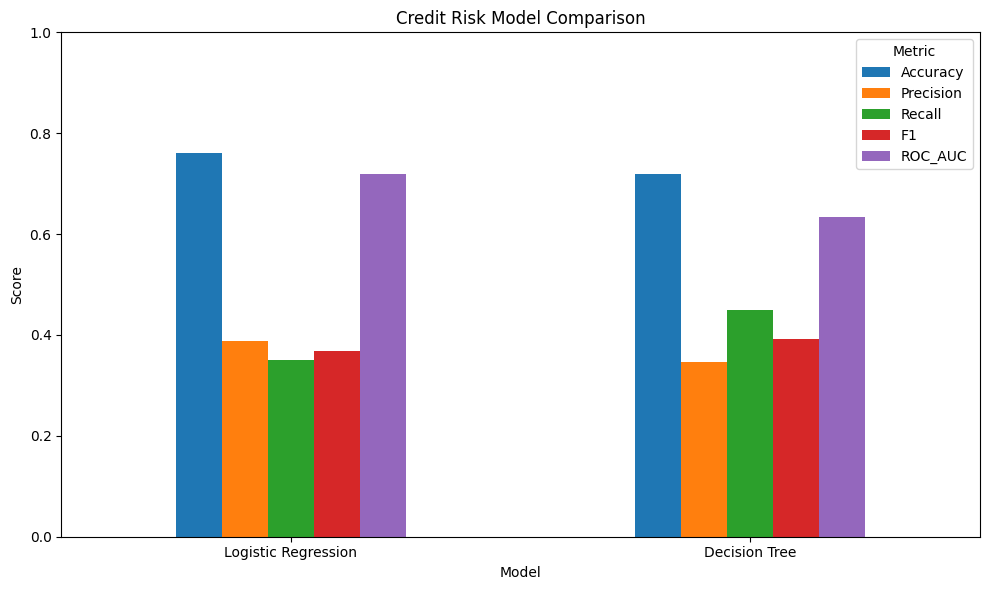

In [77]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"]

comparison_plot = model_comparison.set_index("Model")[metrics]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6))

plt.title("Credit Risk Model Comparison")

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

In [78]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False)

print("Model comparison saved.")

Model comparison saved.


In [79]:
model_predictions = pd.DataFrame({
    "actual_default": y_test.values,
    "logistic_probability": y_prob_logistic,
    "logistic_prediction": y_pred_logistic,
    "tree_probability": y_prob_tree,
    "tree_prediction": y_pred_tree})

model_predictions.head()

,actual_default,logistic_probability,logistic_prediction,tree_probability,tree_prediction
0,0,0.004897,0,0.009524,0
1,0,0.946459,1,1.000000,1
2,0,0.064778,0,0.009524,0
3,0,0.151134,0,0.272727,0
4,0,0.021886,0,0.125000,0


In [80]:
print(model_comparison.to_string(index=False))

              Model  Accuracy  Precision  Recall       F1  ROC_AUC
Logistic Regression      0.76   0.388889    0.35 0.368421 0.718750
      Decision Tree      0.72   0.346154    0.45 0.391304 0.634687


In [81]:
selected_model = logistic_model
selected_probabilities = y_prob_logistic

In [82]:
print("First 10 predicted default probabilities:")
print(np.round(y_prob_logistic[:10], 4))

First 10 predicted default probabilities:
[0.0049 0.9465 0.0648 0.1511 0.0219 0.1647 0.2332 0.0053 0.3056 0.1938]


In [83]:
pricing_df = pd.DataFrame({
    "applicant_id": df.loc[
        X_test.index,
        "applicant_id"
    ].values,

    "actual_default": y_test.values,

    "predicted_default_probability": y_prob_logistic})

pricing_df.head()

,applicant_id,actual_default,predicted_default_probability
0,APP1068,0,0.004897
1,APP1265,0,0.946459
2,APP1267,0,0.064778
3,APP1138,0,0.151134
4,APP1125,0,0.021886


In [84]:
pricing_df["default_probability_pct"] = (
    pricing_df["predicted_default_probability"]
    * 100)

pricing_df.head()

,applicant_id,actual_default,predicted_default_probability,default_probability_pct
0,APP1068,0,0.004897,0.489734
1,APP1265,0,0.946459,94.645907
2,APP1267,0,0.064778,6.477809
3,APP1138,0,0.151134,15.113400
4,APP1125,0,0.021886,2.188625


In [85]:
pricing_df["risk_tier"] = pd.cut(
    pricing_df["predicted_default_probability"],
    bins=[
        -np.inf,
        0.10,
        0.20,
        0.30,
        np.inf],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"])

In [86]:
pricing_df[
    ["predicted_default_probability",
        "risk_tier"]].head(10)

,predicted_default_probability,risk_tier
0,0.004897,Low
1,0.946459,Very High
2,0.064778,Low
3,0.151134,Moderate
4,0.021886,Low
5,0.164709,Moderate
6,0.233166,High
7,0.005309,Low
8,0.305593,Very High
9,0.193780,Moderate


In [87]:
pricing_df["risk_tier"].value_counts(sort=False)

,count
risk_tier,
Low,45
Moderate,16
High,8
Very High,31


In [88]:
base_rate = 0.07
risk_premium_factor = 0.12
maximum_rate = 0.18

In [89]:
pricing_df["risk_premium"] = (risk_premium_factor* pricing_df["predicted_default_probability"])

In [90]:
pricing_df["final_interest_rate"] = (
    base_rate
    + pricing_df["risk_premium"])

In [91]:
pricing_df["final_interest_rate"] = (
    pricing_df["final_interest_rate"]
    .clip(upper=maximum_rate))

In [92]:
pricing_df["final_rate_pct"] = (
    pricing_df["final_interest_rate"]
    * 100)

In [93]:
pricing_df["risk_premium_pct"] = (
    pricing_df["risk_premium"]
    * 100)

In [94]:
pricing_df[
    ["applicant_id",
        "predicted_default_probability",
        "risk_tier",
        "risk_premium_pct",
        "final_rate_pct"]
].head(15)

,applicant_id,predicted_default_probability,risk_tier,risk_premium_pct,final_rate_pct
0,APP1068,0.004897,Low,0.058768,7.058768
1,APP1265,0.946459,Very High,11.357509,18.000000
2,APP1267,0.064778,Low,0.777337,7.777337
3,APP1138,0.151134,Moderate,1.813608,8.813608
4,APP1125,0.021886,Low,0.262635,7.262635
5,APP1030,0.164709,Moderate,1.976511,8.976511
6,APP1054,0.233166,High,2.797993,9.797993
7,APP1192,0.005309,Low,0.063714,7.063714
8,APP1321,0.305593,Very High,3.667120,10.667120
9,APP1299,0.193780,Moderate,2.325363,9.325363


In [95]:
pricing_df.iloc[0][
    ["predicted_default_probability",
        "risk_premium",
        "final_interest_rate"]]

,0
predicted_default_probability,0.004897
risk_premium,0.000588
final_interest_rate,0.070588


In [96]:
print(
    "Maximum final interest rate:",
    pricing_df["final_interest_rate"].max() * 100,
    "%")

Maximum final interest rate: 18.0 %


In [97]:
print(
    "Any rate above 18%?",
    (pricing_df["final_interest_rate"] > 0.18
    ).any())

Any rate above 18%? False


In [98]:
tier_summary = (
    pricing_df
    .groupby("risk_tier", observed=False)
    .agg(
        applicants=("applicant_id", "count"),
        avg_default_probability=(
            "predicted_default_probability",
            "mean"),
        avg_interest_rate=(
            "final_interest_rate",
            "mean"))
    .reset_index())

In [99]:
tier_summary["avg_default_probability"] = (
    tier_summary["avg_default_probability"] * 100)

tier_summary["avg_interest_rate"] = (
    tier_summary["avg_interest_rate"] * 100)

tier_summary

,risk_tier,applicants,avg_default_probability,avg_interest_rate
0,Low,45,3.781927,7.453831
1,Moderate,16,16.004360,8.920523
2,High,8,24.686686,9.962402
3,Very High,31,53.562341,13.415948


In [100]:
pricing_summary = tier_summary.copy()

pricing_summary[
    "avg_default_probability"
] = pricing_summary[
    "avg_default_probability"
].round(2)

pricing_summary[
    "avg_interest_rate"
] = pricing_summary[
    "avg_interest_rate"
].round(2)

pricing_summary

,risk_tier,applicants,avg_default_probability,avg_interest_rate
0,Low,45,3.78,7.45
1,Moderate,16,16.00,8.92
2,High,8,24.69,9.96
3,Very High,31,53.56,13.42


In [101]:
pricing_df.to_csv("risk_based_pricing.csv",index=False)

tier_summary.to_csv("risk_tier_summary.csv",index=False)

print("Pricing files saved.")

Pricing files saved.


In [102]:
behaviour = pd.read_csv("txn_behaviour.csv")

print("Rows:", len(behaviour))
print("Columns:", len(behaviour.columns))

behaviour.head()

Rows: 265
Columns: 6


,txn_id,applicant_id,txn_hour,is_new_device,txn_amount_inr,channel
0,BTXN5000,APP1126,15,0,199,P2P
1,BTXN5001,APP1167,22,0,499,P2P
2,BTXN5002,APP1079,18,0,1999,P2P
3,BTXN5003,APP1293,18,1,999,P2M
4,BTXN5004,APP1332,12,0,199,P2P


In [103]:
behaviour.columns.tolist()

['txn_id',
 'applicant_id',
 'txn_hour',
 'is_new_device',
 'txn_amount_inr',
 'channel']

In [104]:
behaviour["actual_anomaly"] = (
    behaviour["txn_id"].str.startswith("BTXNA")
).astype(int)

In [105]:
behaviour["actual_anomaly"].value_counts()

,count
actual_anomaly,
0,250
1,15


In [106]:
behaviour[
    behaviour["actual_anomaly"] == 0
].head(10)

,txn_id,applicant_id,txn_hour,is_new_device,txn_amount_inr,channel,actual_anomaly
0,BTXN5000,APP1126,15,0,199,P2P,0
1,BTXN5001,APP1167,22,0,499,P2P,0
2,BTXN5002,APP1079,18,0,1999,P2P,0
3,BTXN5003,APP1293,18,1,999,P2M,0
4,BTXN5004,APP1332,12,0,199,P2P,0
5,BTXN5005,APP1125,15,0,199,P2M,0
6,BTXN5006,APP1342,7,0,199,P2M,0
7,BTXN5007,APP1309,9,0,199,P2P,0
8,BTXN5008,APP1149,11,0,199,P2M,0
9,BTXN5009,APP1015,11,0,499,P2P,0


In [107]:
behaviour[
    behaviour["actual_anomaly"] == 1
].head(10)

,txn_id,applicant_id,txn_hour,is_new_device,txn_amount_inr,channel,actual_anomaly
250,BTXNA0,APP1089,2,1,24999,P2P,1
251,BTXNA1,APP1185,3,1,19999,P2P,1
252,BTXNA2,APP1317,1,1,19999,P2P,1
253,BTXNA3,APP1357,4,1,19999,P2P,1
254,BTXNA4,APP1173,4,1,14999,P2P,1
255,BTXNA5,APP1216,4,1,19999,P2P,1
256,BTXNA6,APP1394,4,1,14999,P2P,1
257,BTXNA7,APP1263,2,1,19999,P2P,1
258,BTXNA8,APP1096,2,1,14999,P2P,1
259,BTXNA9,APP1116,3,1,19999,P2P,1


In [108]:
anomaly_features = [
    "txn_hour",
    "is_new_device",
    "txn_amount_inr"]

In [109]:
X_anomaly = behaviour[
    anomaly_features
].copy()

X_anomaly.head()

,txn_hour,is_new_device,txn_amount_inr
0,15,0,199
1,22,0,499
2,18,0,1999
3,18,1,999
4,12,0,199


In [110]:
from sklearn.ensemble import IsolationForest

In [111]:
contamination_rate = 15 / 265

print("Contamination rate:",contamination_rate)

Contamination rate: 0.05660377358490566


In [112]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    random_state=42)

In [113]:
isolation_forest.fit(X_anomaly)

IsolationForest(contamination=0.05660377358490566, n_estimators=200,
                random_state=42)

In [114]:
anomaly_prediction = isolation_forest.predict(
    X_anomaly)

In [115]:
behaviour["predicted_anomaly"] = (
    anomaly_prediction == -1
).astype(int)

In [116]:
behaviour[
    "predicted_anomaly"
].value_counts()

,count
predicted_anomaly,
0,250
1,15


In [117]:
detected_anomalies = behaviour[
    behaviour["predicted_anomaly"] == 1
].copy()

detected_anomalies[[
        "txn_id",
        "txn_hour",
        "is_new_device",
        "txn_amount_inr",
        "channel"]]

,txn_id,txn_hour,is_new_device,txn_amount_inr,channel
3,BTXN5003,18,1,999,P2M
10,BTXN5010,22,1,199,P2P
81,BTXN5081,13,1,3999,P2P
130,BTXN5130,7,1,1999,P2M
157,BTXN5157,20,1,999,P2P
250,BTXNA0,2,1,24999,P2P
253,BTXNA3,4,1,19999,P2P
254,BTXNA4,4,1,14999,P2P
255,BTXNA5,4,1,19999,P2P
256,BTXNA6,4,1,14999,P2P


In [118]:
cm_anomaly = confusion_matrix(
    behaviour["actual_anomaly"],
    behaviour["predicted_anomaly"])

print(cm_anomaly)

[[245   5]
 [  5  10]]


In [119]:
anomaly_precision = precision_score(
    behaviour["actual_anomaly"],
    behaviour["predicted_anomaly"],
    zero_division=0)

print("Anomaly Precision:", round(anomaly_precision, 4))

Anomaly Precision: 0.6667


In [120]:
anomaly_recall = recall_score(
    behaviour["actual_anomaly"],
    behaviour["predicted_anomaly"],
    zero_division=0)

print("Anomaly Recall:", round(anomaly_recall, 4))

Anomaly Recall: 0.6667


In [121]:
anomaly_f1 = f1_score(
    behaviour["actual_anomaly"],
    behaviour["predicted_anomaly"],
    zero_division=0)

print("Anomaly F1:", round(anomaly_f1, 4))

Anomaly F1: 0.6667


In [122]:
true_positives = ((
        behaviour["actual_anomaly"] == 1) &(
        behaviour["predicted_anomaly"] == 1)
).sum()

print("Planted anomalies detected:", true_positives,"out of 15")

Planted anomalies detected: 10 out of 15


In [123]:
anomaly_summary = pd.DataFrame({
    "Metric": [
        "Total transactions",
        "Actual anomalies",
        "Detected anomalies",
        "Anomalies correctly detected",
        "Precision",
        "Recall",
        "F1"],
    "Value": [
        len(behaviour),
        behaviour["actual_anomaly"].sum(),
        behaviour["predicted_anomaly"].sum(),
        true_positives,
        anomaly_precision,
        anomaly_recall,
        anomaly_f1]})

anomaly_summary

,Metric,Value
0,Total transactions,265.000000
1,Actual anomalies,15.000000
2,Detected anomalies,15.000000
3,Anomalies correctly detected,10.000000
4,Precision,0.666667
5,Recall,0.666667
6,F1,0.666667


In [124]:
false_positives = behaviour[
    (behaviour["actual_anomaly"] == 0)
    &
    (behaviour["predicted_anomaly"] == 1)]

false_positives[[
        "txn_id",
        "txn_hour",
        "is_new_device",
        "txn_amount_inr",
        "channel"]]

,txn_id,txn_hour,is_new_device,txn_amount_inr,channel
3,BTXN5003,18,1,999,P2M
10,BTXN5010,22,1,199,P2P
81,BTXN5081,13,1,3999,P2P
130,BTXN5130,7,1,1999,P2M
157,BTXN5157,20,1,999,P2P


In [125]:
false_negatives = behaviour[
    (behaviour["actual_anomaly"] == 1)
    &
    (behaviour["predicted_anomaly"] == 0)]

false_negatives[[
        "txn_id",
        "txn_hour",
        "is_new_device",
        "txn_amount_inr",
        "channel"]]

,txn_id,txn_hour,is_new_device,txn_amount_inr,channel
251,BTXNA1,3,1,19999,P2P
252,BTXNA2,1,1,19999,P2P
257,BTXNA7,2,1,19999,P2P
259,BTXNA9,3,1,19999,P2P
264,BTXNA14,1,1,19999,P2P


In [126]:
behaviour["anomaly_score"] = (
    isolation_forest.decision_function(
        X_anomaly))

In [127]:
behaviour.sort_values(
    "anomaly_score"
).head(20)[[
        "txn_id",
        "txn_hour",
        "is_new_device",
        "txn_amount_inr",
        "channel",
        "anomaly_score",
        "actual_anomaly",
        "predicted_anomaly"]]

,txn_id,txn_hour,is_new_device,txn_amount_inr,channel,anomaly_score,actual_anomaly,predicted_anomaly
261,BTXNA11,1,1,24999,P2P,-0.084650,1,1
81,BTXN5081,13,1,3999,P2P,-0.079330,0,1
10,BTXN5010,22,1,199,P2P,-0.076484,0,1
262,BTXNA12,1,1,14999,P2P,-0.054351,1,1
157,BTXN5157,20,1,999,P2P,-0.033150,0,1
250,BTXNA0,2,1,24999,P2P,-0.030865,1,1
260,BTXNA10,2,1,24999,P2P,-0.030865,1,1
258,BTXNA8,2,1,14999,P2P,-0.029085,1,1
3,BTXN5003,18,1,999,P2M,-0.019311,0,1
130,BTXN5130,7,1,1999,P2M,-0.008070,0,1


In [128]:
behaviour.to_csv(
    "anomaly_detection_results.csv",
    index=False)

anomaly_summary.to_csv(
    "anomaly_summary.csv",
    index=False)

print("Anomaly detection results saved.")

Anomaly detection results saved.


In [129]:
print("ANOMALY CHECK")

print("Total transactions:", len(behaviour))

print("Actual planted anomalies:", behaviour["actual_anomaly"].sum())

print("Detected anomalies:", behaviour["predicted_anomaly"].sum())

print("Correctly detected:", true_positives)

print("Recall:", round(anomaly_recall, 4))

print("Precision:",round(anomaly_precision, 4))

print("F1:", round(anomaly_f1, 4))

ANOMALY CHECK
Total transactions: 265
Actual planted anomalies: 15
Detected anomalies: 15
Correctly detected: 10
Recall: 0.6667
Precision: 0.6667
F1: 0.6667


In [130]:
subgroup_analysis = X_test.copy()

subgroup_analysis["actual_default"] = y_test.values
subgroup_analysis["predicted_default"] = y_pred_logistic
subgroup_analysis["default_probability"] = y_prob_logistic

subgroup_analysis.head()

,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,is_thin_file,actual_default,predicted_default,default_probability
68,APP1068,38,127856,4,0.22,113279,0,612.0,salaried,1,0,0,0.004897
265,APP1265,32,29388,0,0.77,25711,4,391.0,self_employed,0,0,1,0.946459
267,APP1267,42,84836,2,0.20,59993,1,362.0,self_employed,0,0,0,0.064778
138,APP1138,48,51395,2,0.51,29598,0,507.0,salaried,0,0,0,0.151134
125,APP1125,57,138961,0,0.61,8471,0,869.0,self_employed,0,0,0,0.021886


In [131]:
subgroup_analysis["is_thin_file"].value_counts()

,count
is_thin_file,
0,82
1,18


In [132]:
subgroup_analysis["applicant_group"] = (
    subgroup_analysis["is_thin_file"]
    .map({
        0: "Non-Thin-File",
        1: "Thin-File"}))

In [133]:
subgroup_analysis[[
        "applicant_group",
        "is_thin_file",
        "actual_default",
        "predicted_default",
        "default_probability"]
].head()

,applicant_group,is_thin_file,actual_default,predicted_default,default_probability
68,Thin-File,1,0,0,0.004897
265,Non-Thin-File,0,0,1,0.946459
267,Non-Thin-File,0,0,0,0.064778
138,Non-Thin-File,0,0,0,0.151134
125,Non-Thin-File,0,0,0,0.021886


In [134]:
subgroup_analysis[[
        "applicant_group",
        "is_thin_file",
        "actual_default",
        "predicted_default",
        "default_probability"]
].head()

,applicant_group,is_thin_file,actual_default,predicted_default,default_probability
68,Thin-File,1,0,0,0.004897
265,Non-Thin-File,0,0,1,0.946459
267,Non-Thin-File,0,0,0,0.064778
138,Non-Thin-File,0,0,0,0.151134
125,Non-Thin-File,0,0,0,0.021886


In [135]:
group_counts = (
    subgroup_analysis
    .groupby("applicant_group")
    .size()
    .reset_index(name="applicants"))

group_counts

,applicant_group,applicants
0,Non-Thin-File,82
1,Thin-File,18


In [136]:
actual_default_rates = (
    subgroup_analysis
    .groupby("applicant_group")["actual_default"]
    .mean()
    .mul(100)
    .reset_index(name="actual_default_rate_pct"))

actual_default_rates

,applicant_group,actual_default_rate_pct
0,Non-Thin-File,21.951220
1,Thin-File,11.111111


In [137]:
predicted_risk = (
    subgroup_analysis
    .groupby("applicant_group")[
        "default_probability"]
    .mean()
    .mul(100)
    .reset_index(
        name="average_predicted_default_probability_pct"))

predicted_risk

,applicant_group,average_predicted_default_probability_pct
0,Non-Thin-File,22.487747
1,Thin-File,24.454849


In [138]:
group_recall = []

for group in [
    "Non-Thin-File",
    "Thin-File"]:

    subset = subgroup_analysis[
        subgroup_analysis["applicant_group"] == group]

    recall = recall_score(
        subset["actual_default"],
        subset["predicted_default"],
        zero_division=0)

    group_recall.append({
        "Applicant Group": group,
        "Recall": recall})

group_recall = pd.DataFrame(group_recall)

group_recall

,Applicant Group,Recall
0,Non-Thin-File,0.388889
1,Thin-File,0.000000


In [139]:
group_precision = []

for group in [
    "Non-Thin-File",
    "Thin-File"]:

    subset = subgroup_analysis[
        subgroup_analysis["applicant_group"] == group]

    precision = precision_score(
        subset["actual_default"],
        subset["predicted_default"],
        zero_division=0)

    group_precision.append({
        "Applicant Group": group,
        "Precision": precision})

group_precision = pd.DataFrame(group_precision)

group_precision

,Applicant Group,Precision
0,Non-Thin-File,0.5
1,Thin-File,0.0


In [140]:
group_f1 = []

for group in [
    "Non-Thin-File",
    "Thin-File"]:

    subset = subgroup_analysis[
        subgroup_analysis["applicant_group"] == group]

    f1 = f1_score(
        subset["actual_default"],
        subset["predicted_default"],
        zero_division=0)

    group_f1.append({
        "Applicant Group": group,
        "F1": f1})

group_f1 = pd.DataFrame(group_f1)

group_f1

,Applicant Group,F1
0,Non-Thin-File,0.4375
1,Thin-File,0.0000


In [141]:
subgroup_summary = (
    subgroup_analysis
    .groupby("applicant_group")
    .agg(
        applicants=("actual_default", "count"),
        actual_default_rate=(
            "actual_default",
            "mean"),
        average_predicted_risk=(
            "default_probability",
            "mean"))
    .reset_index())

subgroup_summary

,applicant_group,applicants,actual_default_rate,average_predicted_risk
0,Non-Thin-File,82,0.219512,0.224877
1,Thin-File,18,0.111111,0.244548


In [142]:
subgroup_metrics = []

for group in [
    "Non-Thin-File",
    "Thin-File"]:

    subset = subgroup_analysis[
        subgroup_analysis["applicant_group"] == group]

    subgroup_metrics.append({
        "applicant_group": group,
        "applicants": len(subset),
        "actual_default_rate": subset[
            "actual_default"
        ].mean(),
        "average_predicted_risk": subset[
            "default_probability"
        ].mean(),
        "precision": precision_score(
            subset["actual_default"],
            subset["predicted_default"],
            zero_division=0),
        "recall": recall_score(
            subset["actual_default"],
            subset["predicted_default"],
            zero_division=0),
        "f1": f1_score(
            subset["actual_default"],
            subset["predicted_default"],
            zero_division=0)})

subgroup_metrics = pd.DataFrame(
    subgroup_metrics)

subgroup_metrics

,applicant_group,applicants,actual_default_rate,average_predicted_risk,precision,recall,f1
0,Non-Thin-File,82,0.219512,0.224877,0.5,0.388889,0.4375
1,Thin-File,18,0.111111,0.244548,0.0,0.000000,0.0000


In [143]:
subgroup_display = subgroup_metrics.copy()

subgroup_display[
    "actual_default_rate"
] *= 100

subgroup_display[
    "average_predicted_risk"
] *= 100

subgroup_display[
    "actual_default_rate"
] = subgroup_display[
    "actual_default_rate"
].round(2)

subgroup_display[
    "average_predicted_risk"
] = subgroup_display[
    "average_predicted_risk"
].round(2)

subgroup_display[
    ["precision", "recall", "f1"]
] = subgroup_display[
    ["precision", "recall", "f1"]
].round(3)

subgroup_display

,applicant_group,applicants,actual_default_rate,average_predicted_risk,precision,recall,f1
0,Non-Thin-File,82,21.95,22.49,0.5,0.389,0.438
1,Thin-File,18,11.11,24.45,0.0,0.000,0.000


In [144]:
recall_gap = abs(
    subgroup_metrics.loc[
        subgroup_metrics["applicant_group"] == "Non-Thin-File",
        "recall"
    ].iloc[0]
    -
    subgroup_metrics.loc[
        subgroup_metrics["applicant_group"] == "Thin-File",
        "recall"
    ].iloc[0])

print(
    "Recall gap:",
    round(recall_gap, 3))

Recall gap: 0.389


In [145]:
f1_gap = abs(
    subgroup_metrics.loc[
        subgroup_metrics["applicant_group"] == "Non-Thin-File",
        "f1"
    ].iloc[0]
    -
    subgroup_metrics.loc[
        subgroup_metrics["applicant_group"] == "Thin-File",
        "f1"
    ].iloc[0])

print(
    "F1 gap:",
    round(f1_gap, 3))

F1 gap: 0.438


In [146]:
subgroup_display[[
        "applicant_group",
        "actual_default_rate",
        "average_predicted_risk"]]

,applicant_group,actual_default_rate,average_predicted_risk
0,Non-Thin-File,21.95,22.49
1,Thin-File,11.11,24.45


In [147]:
subgroup_display.to_csv(
    "thin_file_bias_analysis.csv",
    index=False)

print("Thin-file bias analysis saved.")

Thin-file bias analysis saved.


In [147]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob_logistic)
plt.savefig("roc_curve.png")

In [148]:
tier_summary["actual_default_rate"] = pricing_df.groupby("risk_tier")["actual_default"].mean() * 100

/tmp/ipykernel_1011/1377550117.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary["actual_default_rate"] = pricing_df.groupby("risk_tier")["actual_default"].mean() * 100


In [149]:
from sklearn.preprocessing import StandardScaler
X_anomaly_scaled = StandardScaler().fit_transform(X_anomaly)
isolation_forest.fit(X_anomaly_scaled)

IsolationForest(contamination=0.05660377358490566, n_estimators=200,
                random_state=42)

In [151]:
import os

bias_note = """
# Bias Awareness and Human Oversight

## Potential Proxy Bias

The credit-risk model does not directly include protected characteristics such as gender or location. However, some of the variables used by the model could act as indirect proxies for characteristics that may be correlated with socioeconomic or demographic groups. For example, employment_type may be associated with different socioeconomic circumstances or geographic labour-market patterns. Monthly income can also reflect unequal access to employment opportunities and may correlate with location or other demographic characteristics. Similarly, credit_bureau_score can reflect differences in access to formal credit and therefore may disadvantage applicants who are new to credit or have limited credit histories.

The thin-file population requires particular attention. Applicants with missing credit bureau scores should not automatically be treated as higher-risk simply because they have less traditional credit history. The model deliberately uses UPI inflow and other alternative signals so that applicants can still be assessed when bureau information is unavailable, but this does not eliminate the possibility of indirect bias.

## Human Oversight and Governance

Before deployment, model performance should be monitored across relevant applicant segments, including thin-file status and employment type. Approval and decline rates, default rates, false-positive rates, and model performance should be reviewed periodically to identify potentially unfair outcomes.

A concrete safeguard should be introduced: **a human reviewer should double-check any thin-file applicant who receives a decline recommendation before the decision becomes final.** Borderline or unusually high-risk decisions should also be eligible for human review. Model thresholds should be reviewed periodically, and the model should not be deployed permanently without ongoing fairness, performance, and outcome monitoring.

Human oversight is therefore an important control alongside the model rather than a replacement for the model.
"""

# Create the directory if it doesn't exist
os.makedirs("credit_risk_lending_ml", exist_ok=True)

with open(
    "credit_risk_lending_ml/bias_awareness.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(bias_note)

print("Created: bias_awareness.md")
print("Word count:", len(bias_note.split()))

Created: bias_awareness.md
Word count: 282


In [152]:
# Display the actual model comparison table
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.76,0.388889,0.35,0.368421,0.718750
1,Decision Tree,0.72,0.346154,0.45,0.391304,0.634687


In [153]:
import os

print(
    "Root README exists:",
    os.path.exists("README.md")
)

Root README exists: False


In [154]:
with open("README.md", "w", encoding="utf-8") as f:
    f.write("# Payments & Fraud Analytics Project\n\n")

print("README.md created successfully.")

README.md created successfully.
